In [26]:
import os
os.chdir(r'C:\Users\hp\Desktop\ML\churn-pipeline')
print("Working directory:", os.getcwd())

Working directory: C:\Users\hp\Desktop\ML\churn-pipeline


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('C:/Users/hp/Desktop/ML/churn-pipeline/data/telco_churn.csv')

print(df.shape)
print("\n")
df.head()


(7043, 21)




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [5]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
print(df['Churn'].value_counts())
print("\nChurn rate:", df['Churn'].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


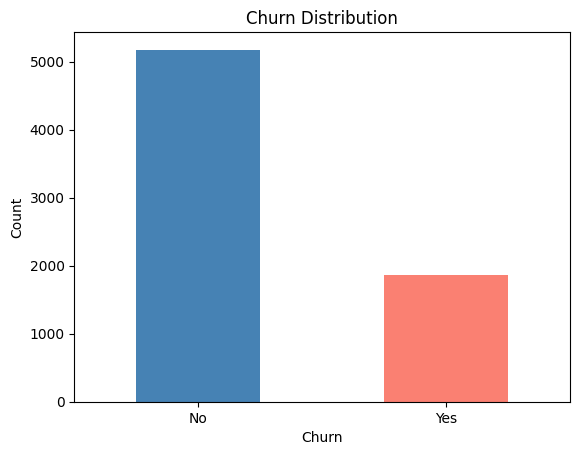

In [7]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [8]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


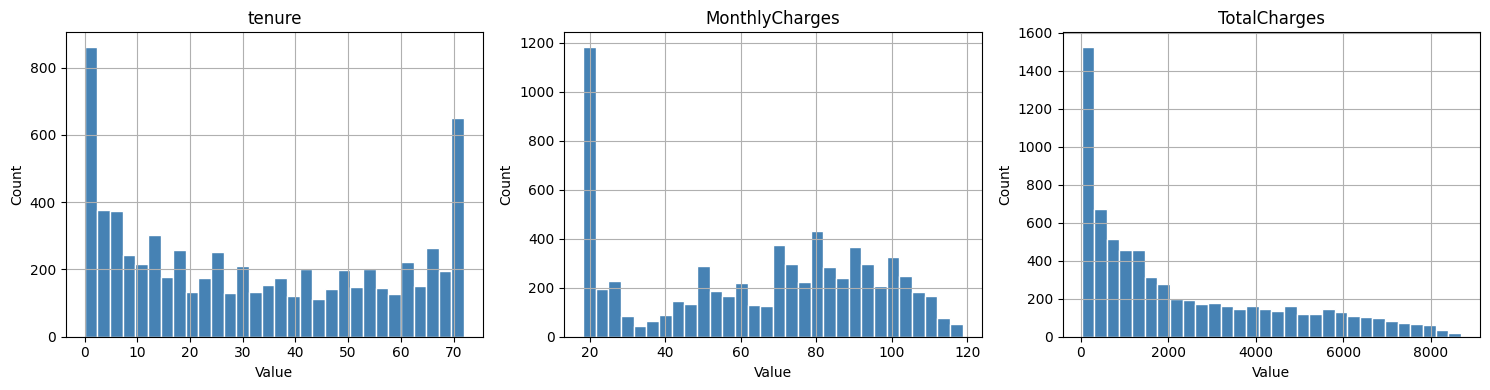

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [10]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


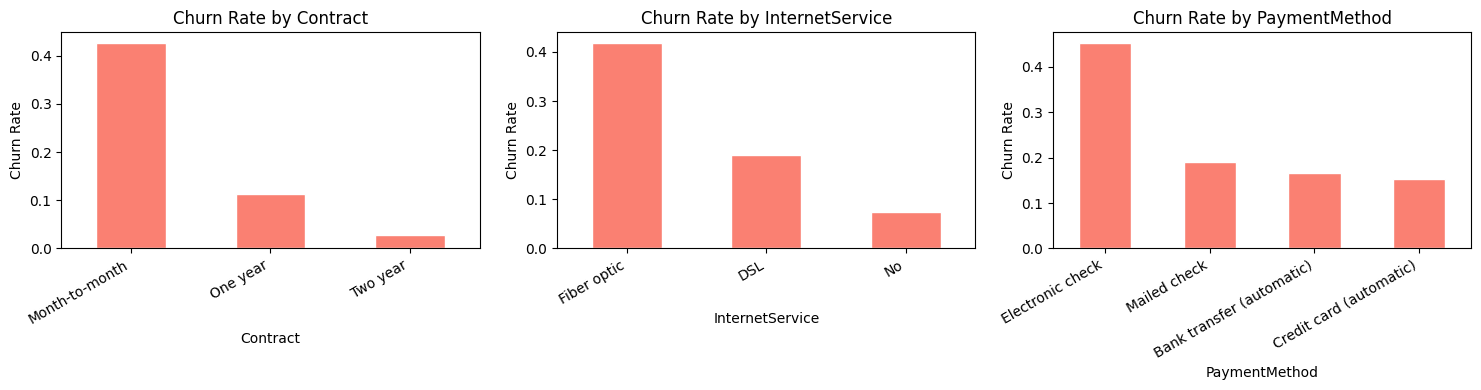

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Contract', 'InternetService', 'PaymentMethod']):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean()
    ).sort_values(ascending=False)
    
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=['customerID'])

df['Churn'] = (df['Churn']=='Yes').astype(int)

X = df.drop(columns=['Churn'])
y = df['Churn']

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")

Train size: (5634, 19)
Test size: (1409, 19)

Train churn rate: 0.265
Test churn rate: 0.265


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib

In [14]:
# Sub-pipeline for numerical columns
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Sub-pipeline for categorical columns
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [15]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [16]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [17]:
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR CV F1:", lr_grid.best_score_.round(4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR params: {'model__C': 10, 'model__solver': 'liblinear'}
Best LR CV F1: 0.5989


In [18]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_.round(4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV F1: 0.5801


In [19]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()
    
    return y_pred

Model: Logistic Regression
Accuracy : 0.8048
F1 Score : 0.6032

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



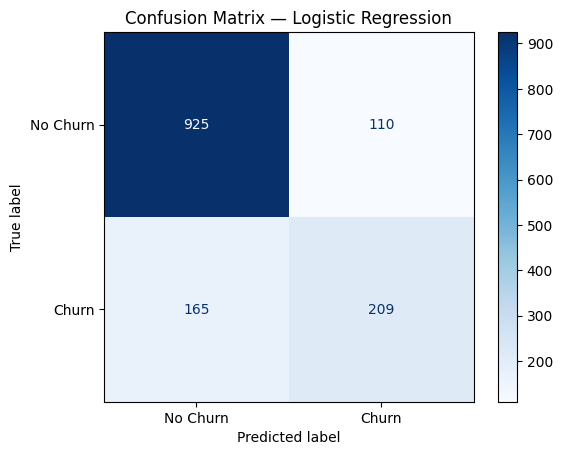

Model: Random Forest
Accuracy : 0.8041
F1 Score : 0.5905

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



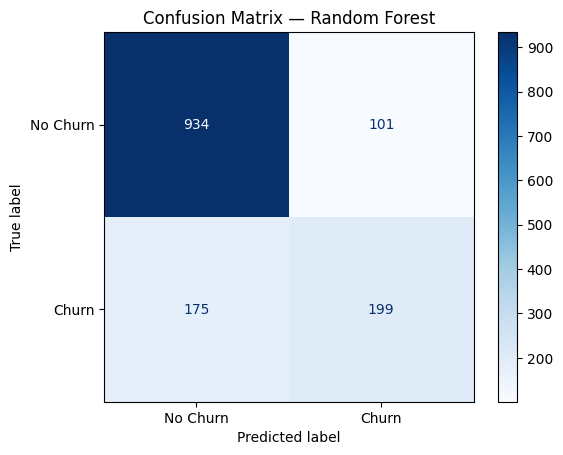

In [20]:
lr_preds = evaluate_model("Logistic Regression", lr_grid.best_estimator_, X_test, y_test)
rf_preds = evaluate_model("Random Forest", rf_grid.best_estimator_, X_test, y_test)

In [27]:
import os
os.makedirs('models', exist_ok=True)

# Pick whichever scored higher on F1
best_model = rf_grid.best_estimator_   # adjust if LR won

joblib.dump(best_model, 'models/churn_pipeline.pkl')
print("Model saved.")

# Verify it works after loading
loaded = joblib.load('models/churn_pipeline.pkl')
test_preds = loaded.predict(X_test)
print("Loaded model F1:", f1_score(y_test, test_preds))

Model saved.
Loaded model F1: 0.5905044510385756


In [22]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("telco-churn-pipeline")

with mlflow.start_run(run_name="random_forest_best"):

    # Log the best hyperparameters GridSearch found
    mlflow.log_params(rf_grid.best_params_)

    # Evaluate
    y_pred = rf_grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("cv_f1", rf_grid.best_score_)

    # Log the full pipeline as an artifact
    mlflow.sklearn.log_model(rf_grid.best_estimator_, "churn_model")

    # Log the saved pkl file too
    mlflow.log_artifact("models/churn_pipeline.pkl")

    print(f"Run logged. Accuracy: {acc:.4f} | F1: {f1:.4f}")

2026/05/21 15:47:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 15:47:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged. Accuracy: 0.8041 | F1: 0.5905


In [23]:
with mlflow.start_run(run_name="logistic_regression_best"):

    mlflow.log_params(lr_grid.best_params_)

    y_pred = lr_grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("cv_f1", lr_grid.best_score_)

    mlflow.sklearn.log_model(lr_grid.best_estimator_, "churn_model")

    print(f"Run logged. Accuracy: {acc:.4f} | F1: {f1:.4f}")

2026/05/21 15:47:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 15:47:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged. Accuracy: 0.8048 | F1: 0.6032


C:\Users\hp\AppData\Local\Temp\ipykernel_9828\135185179.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_r')


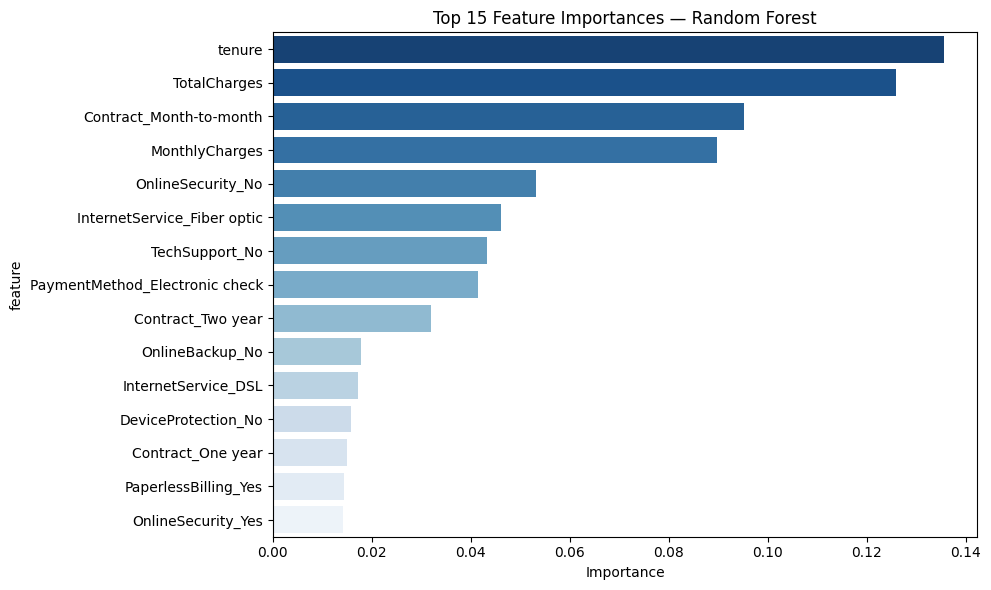

In [24]:
# Get feature names after preprocessing
ohe_feature_names = (
    rf_grid.best_estimator_
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

all_feature_names = numerical_cols + list(ohe_feature_names)

# Get importances from the RF model
importances = (
    rf_grid.best_estimator_
    .named_steps['model']
    .feature_importances_
)

# Sort and plot top 15
feat_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [25]:
import os
print(os.getcwd())

C:\Users\hp\Desktop\ML\churn-pipeline\notebook
